In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import scanpy as sc
import episcanpy as epi
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

import glob
import os

from pathlib import Path
from scipy import io
from helps import *

# Raw CM

## Peak & GEX

In [3]:
adata=sc.read_h5ad("../TopicModelling/Datasets/BMMCMultiOme/RawFiles/GSE194122_openproblems_neurips2021_multiome_BMMC_processed.h5ad")
adata

AnnData object with n_obs × n_vars = 69249 × 129921
    obs: 'GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_blacklist_fraction', 'ATAC_nucleosome_signal', 'cell_type', 'batch', 'ATAC_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker'
    var: 'feature_types', 'gene_id'
    uns: 'ATAC_gene_activity_var_names', 'dataset_id', 'genome', 'organism'
    obsm: 'ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATAC_umap', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'

In [4]:
adata = adata[adata.obs["Samplename"] == "site1_donor1_multiome"]
adata

View of AnnData object with n_obs × n_vars = 6224 × 129921
    obs: 'GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_blacklist_fraction', 'ATAC_nucleosome_signal', 'cell_type', 'batch', 'ATAC_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker'
    var: 'feature_types', 'gene_id'
    uns: 'ATAC_gene_activity_var_names', 'dataset_id', 'genome', 'organism'
    obsm: 'ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATAC_umap', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'

In [5]:
rna = adata[:, adata.var["feature_types"] == "GEX"]
atac = adata[:, adata.var["feature_types"] == "ATAC"]

rna.obs["CellType"] = rna.obs["cell_type"]
atac.obs["CellType"] = atac.obs["cell_type"]

rna.X=rna.layers["counts"]
rna.layers["raw"]=rna.layers["counts"]
del rna.layers["counts"]
atac.X=atac.layers["counts"]
atac.layers["raw"]=atac.layers["counts"]
del atac.layers["counts"]

In [ ]:
atac.var["chr"]=[ind.split("-")[0] for ind in atac.var.index]
atac.var["start"]=[ind.split("-")[1] for ind in atac.var.index]
atac.var["stop"]=[ind.split("-")[2] for ind in atac.var.index]

atac = atac[:,atac.var[atac.var['chr'].str.match('chr')].index]
atac = atac[:,atac.var[~atac.var['chr'].str.match('chrM')].index]
atac.var.index=["_".join([ind.split("-")[0],ind.split("-")[1],ind.split("-")[2]]) for ind in atac.var.index]
atac.var.head()

In [ ]:
sc.pp.scrublet(rna)

In [ ]:
Path("Datasets/BMMCMultiOme/CM/").mkdir(parents=True, exist_ok=True)
rna.write("Datasets/BMMCMultiOme/CM/BMMCMultiOme_GEX_Raw.h5ad", compression="gzip")
atac.write("Datasets/BMMCMultiOme/CM/BMMCMultiOme_Peak_Raw.h5ad", compression="gzip")

## mRNA

In [ ]:
adata=sc.read_h5ad("Datasets/BMMCMultiOme/CM/BMMCMultiOme_GEX_Raw.h5ad")
adata

In [ ]:
names = ["chr", "source", "type", "start", "stop", "score", "strand", "frame", "attribute"]
gtf_file="../AnnotRef/hs/T2T/GCF_009914755.1_T2T-CHM13v2.0_genomic.gtf.gz"
gtf=pd.read_csv(gtf_file, sep="\t", header=None, comment="#", names=names, dtype={"chr": str})
gtf=gtf[(gtf["type"]=="gene") & (gtf["source"]=="BestRefSeq")]

gene_names=[attr.replace("gene_id", "").strip().strip("\"") for feature_attr in gtf.attribute for attr in feature_attr.split(";") if attr.strip().startswith("gene_id")]
tmp = [attr.replace("gene_type", "").strip().strip("\"") for feature_attr in gtf.attribute for attr in feature_attr.split(";") if attr.strip().startswith("gene_type ")]
if not tmp:
    tmp = [attr.replace("gene_biotype", "").strip().strip("\"") for feature_attr in gtf.attribute for attr in feature_attr.split(";") if attr.strip().startswith("gene_biotype ")]

info=pd.DataFrame(data=[gene_names,tmp], index=["GeneName","GeneType"]).T
info.head()

mRNA=adata[:, intersection([adata.var.index, info[info["GeneType"]=="protein_coding"]["GeneName"]])]
mRNA.X=scipy.sparse.csr_matrix(mRNA.X.copy())
mRNA.layers["raw"]=scipy.sparse.csr_matrix(mRNA.X.copy())
mRNA

In [ ]:
mRNA.write("Datasets/BMMCMultiOme/CM/BMMCMultiOme_mRNA_Raw.h5ad", compression="gzip")

## lncRNA

In [ ]:
adata=sc.read_h5ad("Datasets/BMMCMultiOme/CM/BMMCMultiOme_GEX_Raw.h5ad")
adata

In [ ]:
names = ["chr", "source", "type", "start", "stop", "score", "strand", "frame", "attribute"]
gtf_file="../AnnotRef/hs/T2T/GCF_009914755.1_T2T-CHM13v2.0_genomic.gtf.gz"
gtf=pd.read_csv(gtf_file, sep="\t", header=None, comment="#", names=names, dtype={"chr": str})
gtf=gtf[(gtf["type"]=="gene") & (gtf["source"]=="BestRefSeq")]

gene_names=[attr.replace("gene_id", "").strip().strip("\"") for feature_attr in gtf.attribute for attr in feature_attr.split(";") if attr.strip().startswith("gene_id")]
tmp = [attr.replace("gene_type", "").strip().strip("\"") for feature_attr in gtf.attribute for attr in feature_attr.split(";") if attr.strip().startswith("gene_type ")]
if not tmp:
    tmp = [attr.replace("gene_biotype", "").strip().strip("\"") for feature_attr in gtf.attribute for attr in feature_attr.split(";") if attr.strip().startswith("gene_biotype ")]

info=pd.DataFrame(data=[gene_names,tmp], index=["GeneName","GeneType"]).T
info.head()

lncRNA=adata[:, intersection([adata.var.index, info[info["GeneType"]=="lncRNA"]["GeneName"]])]
lncRNA.X=scipy.sparse.csr_matrix(lncRNA.X.copy())
lncRNA.layers["raw"]=scipy.sparse.csr_matrix(lncRNA.X.copy())
lncRNA

In [ ]:
lncRNA.write("Datasets/BMMCMultiOme/CM/BMMCMultiOme_lncRNA_Raw.h5ad", compression="gzip")

# Processing

## Peak

In [5]:
adata=sc.read_h5ad("Datasets/BMMCMultiOme/CM/BMMCMultiOme_Peak_Raw.h5ad")
adata.layers["raw"]=scipy.sparse.csr_matrix(adata.X.copy())
del adata.layers["counts"]
adata

AnnData object with n_obs × n_vars = 6224 × 116468
    obs: 'GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_blacklist_fraction', 'ATAC_nucleosome_signal', 'cell_type', 'batch', 'ATAC_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'CellType'
    var: 'feature_types', 'gene_id', 'chr', 'start', 'stop'
    uns: 'ATAC_gene_activity_var_names', 'dataset_id', 'genome', 'organism'
    obsm: 'ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATAC_umap', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'raw'

In [ ]:
epi.pp.qc_stats(adata, verbose=True)

In [ ]:
min_features = 10**np.quantile(adata.obs["log_n_features"], 0.05)
max_features = 10**np.quantile(adata.obs["log_n_features"], 0.95)
min_cells = 10**np.quantile(adata.var["log_n_cells"], 0.05)
max_cells = 10**np.quantile(adata.var["log_n_cells"], 0.95)

In [ ]:
epi.pl.histogram(adata, "n_features", min_threshold=min_features, max_threshold=max_features, show_log=True)

In [ ]:
epi.pl.histogram(adata, "n_cells", min_threshold=min_cells, max_threshold=max_cells, show_log=True)

In [ ]:
epi.pp.set_filter(adata, "n_features", min_threshold=min_features, max_threshold=max_features, verbose=False)
epi.pp.set_filter(adata, "n_cells", min_threshold=min_cells, max_threshold=max_cells, verbose=False)
adata = epi.pp.apply_filters(adata, verbose=False)
adata

In [ ]:
epi.pp.normalize_total(adata)

In [ ]:
sc.pp.highly_variable_genes(adata, flavor='seurat_v3')

In [ ]:
min_var = np.quantile(adata.var.variances_norm, 0.7)

In [ ]:
adata=adata[:, adata.var.variances_norm>min_var]

In [ ]:
adata = adata[:, adata.X.max(axis=0)>0]
adata = adata[adata.X.max(axis=1)>0]

In [ ]:
adata

In [ ]:
adata.write("Datasets/BMMCMultiOme/CM/BMMCMultiOme_Peak_Def.h5ad", compression="gzip")

## GEX

In [6]:
adata=sc.read_h5ad("Datasets/BMMCMultiOme/CM/BMMCMultiOme_GEX_Raw.h5ad")
adata.layers["raw"]=scipy.sparse.csr_matrix(adata.X.copy())
del adata.layers["counts"]
adata

AnnData object with n_obs × n_vars = 6224 × 13431
    obs: 'GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_blacklist_fraction', 'ATAC_nucleosome_signal', 'cell_type', 'batch', 'ATAC_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'CellType', 'doublet_score', 'predicted_doublet'
    var: 'feature_types', 'gene_id'
    uns: 'ATAC_gene_activity_var_names', 'dataset_id', 'genome', 'organism', 'scrublet'
    obsm: 'ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATAC_umap', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'raw'

In [ ]:
epi.pp.qc_stats(adata, verbose=False)
mt_gene_mask = np.flatnonzero([gene.startswith(("MT","mt")) for gene in adata.var.index])
adata.obs['mt_frac'] = np.sum(adata[:, mt_gene_mask].X, axis=1).A1/adata.obs['n_counts']

In [ ]:
min_features = 10**np.quantile(adata.obs["log_n_features"], 0.05)
max_features = 10**np.quantile(adata.obs["log_n_features"], 0.95)
min_cells = 10**np.quantile(adata.var["log_n_cells"], 0.05)
max_cells = 10**np.quantile(adata.var["log_n_cells"], 0.95)

In [ ]:
epi.pl.histogram(adata, "n_features", min_threshold=min_features, max_threshold=max_features, show_log=True)

In [ ]:
epi.pl.histogram(adata, "n_cells", min_threshold=min_cells, max_threshold=max_cells, show_log=True)

In [ ]:
epi.pl.histogram(adata, "mt_frac", max_threshold=0.05, show_log=False)

In [ ]:
epi.pp.set_filter(adata, "n_features", min_threshold=min_features, max_threshold=max_features, verbose=False)
epi.pp.set_filter(adata, "n_cells", min_threshold=min_cells, max_threshold=max_cells, verbose=False)
adata = epi.pp.apply_filters(adata, verbose=False)
adata = adata[adata.obs["mt_frac"]<=0.05]
adata=adata[adata.obs.predicted_doublet==False]
adata

In [ ]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

In [ ]:
sc.pp.highly_variable_genes(adata, flavor='seurat_v3')
min_var = np.quantile(adata.var.variances_norm, 0.7)
adata=adata[:, adata.var.variances_norm>min_var]
adata = adata[:, adata.X.max(axis=0)>0]
adata = adata[adata.X.max(axis=1)>0]
adata

In [ ]:
adata.write("Datasets/BMMCMultiOme/CM/BMMCMultiOme_GEX_Def.h5ad", compression="gzip")

## mRNA

In [7]:
adata=sc.read_h5ad("Datasets/BMMCMultiOme/CM/BMMCMultiOme_mRNA_Raw.h5ad")
adata.layers["raw"]=scipy.sparse.csr_matrix(adata.X.copy())
del adata.layers["counts"]
adata

AnnData object with n_obs × n_vars = 6224 × 4658
    obs: 'GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_blacklist_fraction', 'ATAC_nucleosome_signal', 'cell_type', 'batch', 'ATAC_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'CellType', 'doublet_score', 'predicted_doublet'
    var: 'feature_types', 'gene_id'
    uns: 'ATAC_gene_activity_var_names', 'dataset_id', 'genome', 'organism', 'scrublet'
    obsm: 'ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATAC_umap', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'raw'

In [5]:
epi.pp.qc_stats(adata, verbose=False)
mt_gene_mask = np.flatnonzero([gene.startswith(("MT","mt")) for gene in adata.var.index])
adata.obs['mt_frac'] = np.sum(adata[:, mt_gene_mask].X, axis=1).A1/adata.obs['n_counts']

In [6]:
min_features = 10**np.quantile(adata.obs["log_n_features"], 0.05)
max_features = 10**np.quantile(adata.obs["log_n_features"], 0.95)
min_cells = 10**np.quantile(adata.var["log_n_cells"], 0.05)
max_cells = 10**np.quantile(adata.var["log_n_cells"], 0.95)

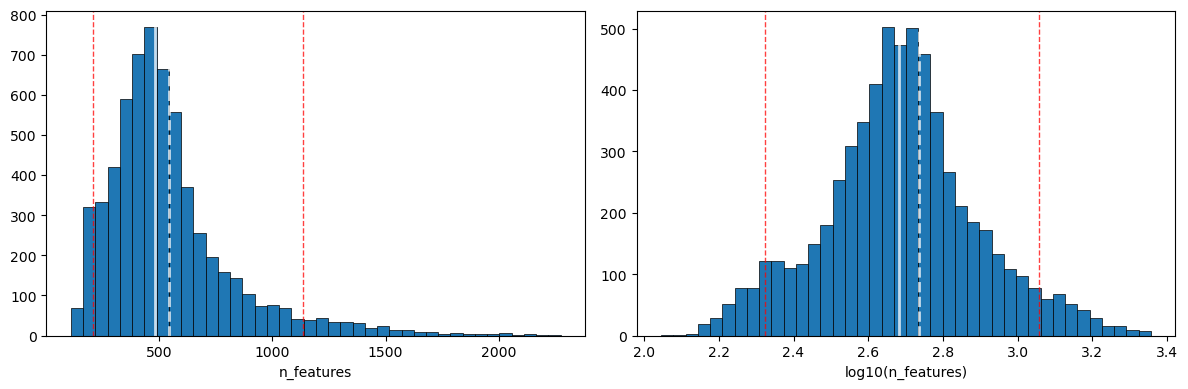

Max:	2273
Median:	482.0
Mean:	544.0412917737789
Min:	111


In [7]:
epi.pl.histogram(adata, "n_features", min_threshold=min_features, max_threshold=max_features, show_log=True)

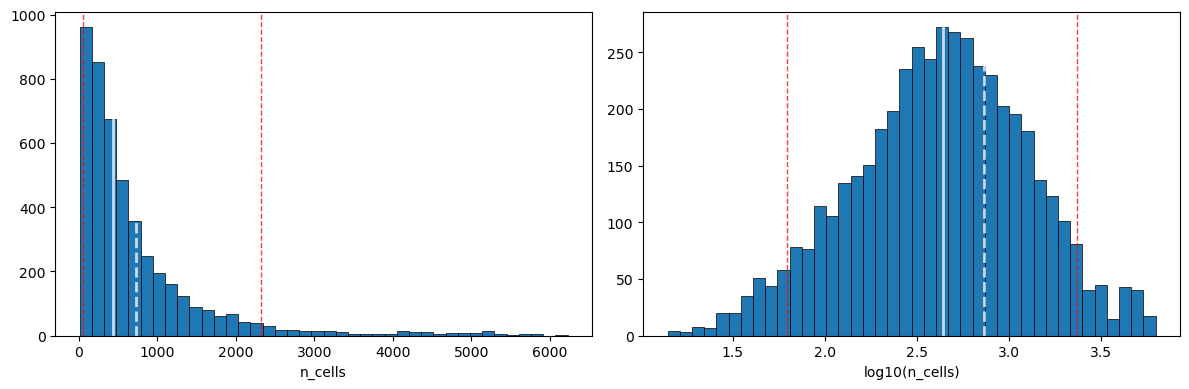

Max:	6224
Median:	439.0
Mean:	726.9456848432803
Min:	14


In [8]:
epi.pl.histogram(adata, "n_cells", min_threshold=min_cells, max_threshold=max_cells, show_log=True)

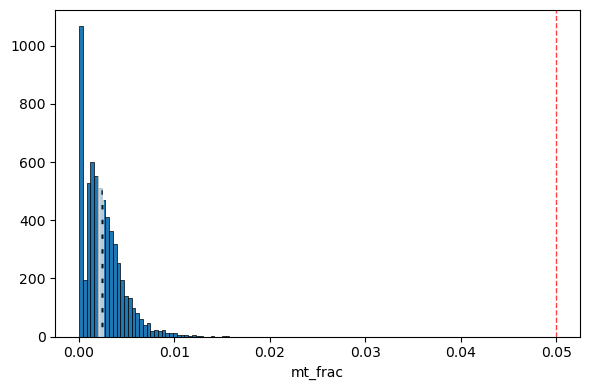

Max:	0.015748031437397003
Median:	0.0020958869718015194
Mean:	0.0024526987690478563
Min:	0.0


In [9]:
epi.pl.histogram(adata, "mt_frac", max_threshold=0.05, show_log=False)

In [10]:
epi.pp.set_filter(adata, "n_features", min_threshold=min_features, max_threshold=max_features, verbose=False)
epi.pp.set_filter(adata, "n_cells", min_threshold=min_cells, max_threshold=max_cells, verbose=False)
adata = epi.pp.apply_filters(adata, verbose=False)
adata = adata[adata.obs["mt_frac"]<=0.05]
adata=adata[adata.obs.predicted_doublet==False]
adata

View of AnnData object with n_obs × n_vars = 5594 × 4193
    obs: 'GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_blacklist_fraction', 'ATAC_nucleosome_signal', 'cell_type', 'batch', 'ATAC_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'CellType', 'doublet_score', 'predicted_doublet', 'n_features', 'log_n_features', 'n_counts', 'log_n_counts', 'mt_frac', 'passes_filter'
    var: 'feature_types', 'gene_id', 'n_cells', 'log_n_cells', 'passes_filter'
    uns: 'ATAC_gene_activity_var_names', 'dataset_id', 'genome', 'organism', 'scrublet'
    obsm: 'ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATAC_umap', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'

In [11]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

In [12]:
sc.pp.highly_variable_genes(adata, flavor='seurat_v3')
min_var = np.quantile(adata.var.variances_norm, 0.7)
adata=adata[:, adata.var.variances_norm>min_var]
adata = adata[:, adata.X.max(axis=0)>0]
adata = adata[adata.X.max(axis=1)>0]
adata

View of AnnData object with n_obs × n_vars = 5594 × 1258
    obs: 'GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_blacklist_fraction', 'ATAC_nucleosome_signal', 'cell_type', 'batch', 'ATAC_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'CellType', 'doublet_score', 'predicted_doublet', 'n_features', 'log_n_features', 'n_counts', 'log_n_counts', 'mt_frac', 'passes_filter'
    var: 'feature_types', 'gene_id', 'n_cells', 'log_n_cells', 'passes_filter', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'ATAC_gene_activity_var_names', 'dataset_id', 'genome', 'organism', 'scrublet', 'log1p', 'hvg'
    obsm: 'ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATA

In [13]:
adata.write("Datasets/BMMCMultiOme/CM/BMMCMultiOme_mRNA_Def.h5ad", compression="gzip")

## lncRNA

In [8]:
adata=sc.read_h5ad("Datasets/BMMCMultiOme/CM/BMMCMultiOme_lncRNA_Raw.h5ad")
adata.layers["raw"]=scipy.sparse.csr_matrix(adata.X.copy())
del adata.layers["counts"]
adata

AnnData object with n_obs × n_vars = 6224 × 598
    obs: 'GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_blacklist_fraction', 'ATAC_nucleosome_signal', 'cell_type', 'batch', 'ATAC_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'CellType', 'doublet_score', 'predicted_doublet'
    var: 'feature_types', 'gene_id'
    uns: 'ATAC_gene_activity_var_names', 'dataset_id', 'genome', 'organism', 'scrublet'
    obsm: 'ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATAC_umap', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'raw'

In [25]:
epi.pp.qc_stats(adata, verbose=False)
mt_gene_mask = np.flatnonzero([gene.startswith(("MT","mt")) for gene in adata.var.index])
adata.obs['mt_frac'] = np.sum(adata[:, mt_gene_mask].X, axis=1).A1/adata.obs['n_counts']

In [26]:
min_features = 10**np.quantile(adata.obs["log_n_features"], 0.05)
max_features = 10**np.quantile(adata.obs["log_n_features"], 0.95)
min_cells = 10**np.quantile(adata.var["log_n_cells"], 0.05)
max_cells = 10**np.quantile(adata.var["log_n_cells"], 0.95)

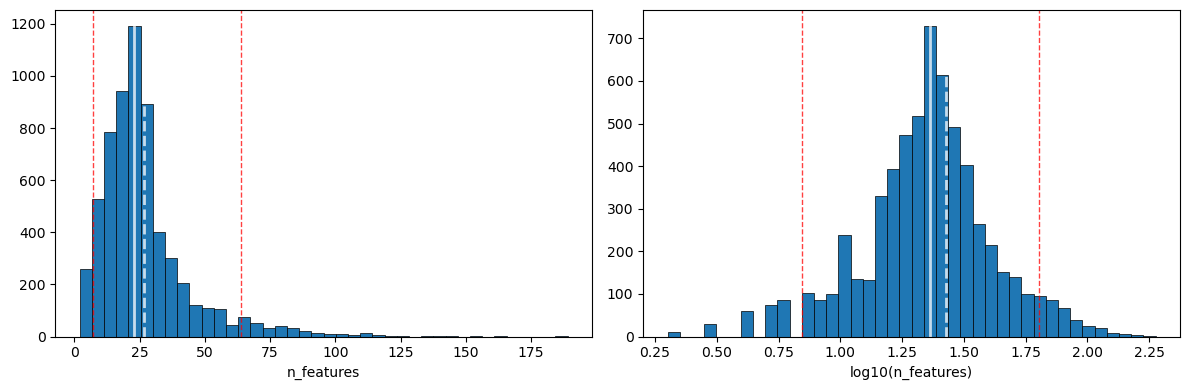

Max:	189
Median:	23.0
Mean:	26.82487146529563
Min:	2


In [27]:
epi.pl.histogram(adata, "n_features", min_threshold=min_features, max_threshold=max_features, show_log=True)

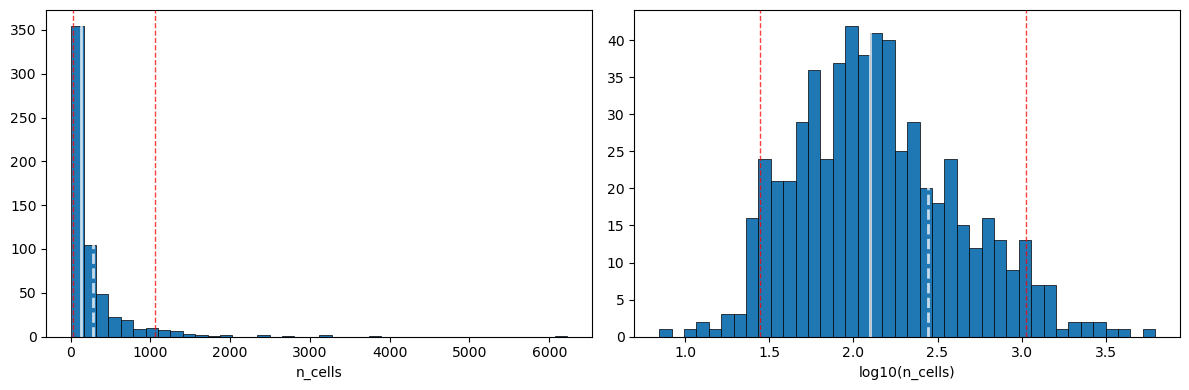

Max:	6224
Median:	125.5
Mean:	279.19397993311037
Min:	7


In [28]:
epi.pl.histogram(adata, "n_cells", min_threshold=min_cells, max_threshold=max_cells, show_log=True)

In [29]:
epi.pp.set_filter(adata, "n_features", min_threshold=min_features, max_threshold=max_features, verbose=False)
epi.pp.set_filter(adata, "n_cells", min_threshold=min_cells, max_threshold=max_cells, verbose=False)
adata = epi.pp.apply_filters(adata, verbose=False)
adata=adata[adata.obs.predicted_doublet==False]
adata

View of AnnData object with n_obs × n_vars = 5643 × 541
    obs: 'GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_blacklist_fraction', 'ATAC_nucleosome_signal', 'cell_type', 'batch', 'ATAC_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'CellType', 'doublet_score', 'predicted_doublet', 'n_features', 'log_n_features', 'n_counts', 'log_n_counts', 'mt_frac', 'passes_filter'
    var: 'feature_types', 'gene_id', 'n_cells', 'log_n_cells', 'passes_filter'
    uns: 'ATAC_gene_activity_var_names', 'dataset_id', 'genome', 'organism', 'scrublet'
    obsm: 'ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATAC_umap', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'

In [30]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

In [31]:
sc.pp.highly_variable_genes(adata, flavor='seurat_v3')
min_var = np.quantile(adata.var.variances_norm, 0.1)
adata=adata[:, adata.var.variances_norm>min_var]
adata = adata[:, adata.X.max(axis=0)>0]
adata = adata[adata.X.max(axis=1)>0]
adata

View of AnnData object with n_obs × n_vars = 5643 × 486
    obs: 'GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_blacklist_fraction', 'ATAC_nucleosome_signal', 'cell_type', 'batch', 'ATAC_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'CellType', 'doublet_score', 'predicted_doublet', 'n_features', 'log_n_features', 'n_counts', 'log_n_counts', 'mt_frac', 'passes_filter'
    var: 'feature_types', 'gene_id', 'n_cells', 'log_n_cells', 'passes_filter', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'ATAC_gene_activity_var_names', 'dataset_id', 'genome', 'organism', 'scrublet', 'log1p', 'hvg'
    obsm: 'ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATAC

In [32]:
adata.write("Datasets/BMMCMultiOme/CM/BMMCMultiOme_lncRNA_Def.h5ad", compression="gzip")

## Muon objects

In [13]:
import muon as mu
peak=sc.read_h5ad(f"Datasets/BMMCMultiOme/CM/BMMCMultiOme_Peak_Def.h5ad")
gex=sc.read_h5ad(f"Datasets/BMMCMultiOme/CM/BMMCMultiOme_GEX_Def.h5ad")
mrna=sc.read_h5ad(f"Datasets/BMMCMultiOme/CM/BMMCMultiOme_mRNA_Def.h5ad")
lncrna=sc.read_h5ad(f"Datasets/BMMCMultiOme/CM/BMMCMultiOme_lncRNA_Def.h5ad")

#Peak + GEX
print("Peak + GEX")
inter=intersection([peak.obs.index, gex.obs.index])
mudata=mu.MuData({"Peak" : peak[inter], "GEX" : gex[inter]})
mudata.write_h5mu(f"Datasets/BMMCMultiOme/CM/BMMCMultiOme_Peak_GEX_Def.h5mu", compression="gzip")

#Peak + mRNA
print("Peak + mRNA")
inter=intersection([peak.obs.index, mrna.obs.index])
mudata=mu.MuData({"Peak" : peak[inter], "mRNA" : mrna[inter]})
mudata.write_h5mu(f"Datasets/BMMCMultiOme/CM/BMMCMultiOme_Peak_mRNA_Def.h5mu", compression="gzip")

#Peak + lncRNA
print("Peak + lncRNA")
inter=intersection([peak.obs.index, lncrna.obs.index])
mudata=mu.MuData({"Peak" : peak[inter], "lncRNA" : lncrna[inter]})
mudata.write_h5mu(f"Datasets/BMMCMultiOme/CM/BMMCMultiOme_Peak_lncRNA_Def.h5mu", compression="gzip")

#mRNA + lncRNA
print("mRNA + lncRNA")
inter=intersection([mrna.obs.index, lncrna.obs.index])
mudata=mu.MuData({"mRNA" : mrna[inter], "lncRNA" : lncrna[inter]})
mudata.write_h5mu(f"Datasets/BMMCMultiOme/CM/BMMCMultiOme_mRNA_lncRNA_Def.h5mu", compression="gzip")

#Peak + mRNA + lncRNA
print("Peak + mRNA + lncRNA")
inter=intersection([peak.obs.index, mrna.obs.index, lncrna.obs.index])
mudata=mu.MuData({"Peak" : peak[inter], "mRNA" : mrna[inter], "lncRNA" : lncrna[inter]})
mudata.write_h5mu(f"Datasets/BMMCMultiOme/CM/BMMCMultiOme_Peak_mRNA_lncRNA_Def.h5mu", compression="gzip")

Peak + GEX
Peak + mRNA
Peak + lncRNA
mRNA + lncRNA
Peak + mRNA + lncRNA


In [14]:
mudata

MuData object with n_obs × n_vars = 5084 × 33411
  var:	'feature_types', 'gene_id', 'n_cells', 'log_n_cells', 'passes_filter', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
  3 modalities
    Peak:	5084 x 31667
      obs:	'GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_blacklist_fraction', 'ATAC_nucleosome_signal', 'cell_type', 'batch', 'ATAC_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'CellType', 'n_features', 'log_n_features', 'n_counts', 'log_n_counts', 'passes_filter'
      var:	'feature_types', 'gene_id', 'chr', 'start', 'stop', 'n_cells', 'log_n_cells', 'passes_filter', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
      uns:	'ATAC_gene_activity_var_names', 'Mod', 'dataset_id', 'genome', 'hvg', 'organism'
      obsm:	'ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATAC_umap', 'GEX_X_pca', 'GEX_X_umap'
      layers:	'counts', 'raw'
    mRNA:	5084 x 1258
      obs:	'GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_blacklist_fraction', 'ATAC_nucleosome_signal', 'cell_type', 'batch', 'ATAC_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'CellType', 'doublet_score', 'predicted_doublet', 'n_features', 'log_n_features', 'n_counts', 'log_n_counts', 'mt_frac', 'passes_filter'
      var:	'feature_types', 'gene_id', 'n_cells', 'log_n_cells', 'passes_filter', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
      uns:	'ATAC_gene_activity_var_names', 'Mod', 'dataset_id', 'genome', 'hvg', 'log1p', 'organism', 'scrublet'
      obsm:	'ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATAC_umap', 'GEX_X_pca', 'GEX_X_umap'
      layers:	'counts', 'raw'
    lncRNA:	5084 x 486
      obs:	'GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_blacklist_fraction', 'ATAC_nucleosome_signal', 'cell_type', 'batch', 'ATAC_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'CellType', 'doublet_score', 'predicted_doublet', 'n_features', 'log_n_features', 'n_counts', 'log_n_counts', 'mt_frac', 'passes_filter'
      var:	'feature_types', 'gene_id', 'n_cells', 'log_n_cells', 'passes_filter', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
      uns:	'ATAC_gene_activity_var_names', 'Mod', 'dataset_id', 'genome', 'hvg', 'log1p', 'organism', 'scrublet'
      obsm:	'ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATAC_umap', 'GEX_X_pca', 'GEX_X_umap'
      layers:	'counts', 'raw'

# CTA

In [2]:
df=sc.read_h5ad("Datasets/BMMCMultiOme/CM/BMMCMultiOme_GEX_Raw.h5ad").obs
df.head()

,GEX_pct_counts_mt,GEX_n_counts,GEX_n_genes,GEX_size_factors,GEX_phase,ATAC_nCount_peaks,ATAC_atac_fragments,ATAC_reads_in_peaks_frac,ATAC_blacklist_fraction,ATAC_nucleosome_signal,...,DonorBMI,DonorBloodType,DonorRace,Ethnicity,DonorGender,QCMeds,DonorSmoker,CellType,doublet_score,predicted_doublet
TAGTTGTCACCCTCAC-1-s1d1,1.061008,1508.0,1022,0.453484,S,4031.0,5400,0.746481,0.003473,0.642468,...,24.8,B-,White,HISPANIC OR LATINO,Male,False,Nonsmoker,Naive CD20+ B,0.008408,False
CTATGGCCATAACGGG-1-s1d1,0.604230,1655.0,1081,0.455631,G2M,8636.0,19266,0.448251,0.003126,1.220679,...,24.8,B-,White,HISPANIC OR LATINO,Male,False,Nonsmoker,CD14+ Mono,0.014151,False
CCGCACACAGGTTAAA-1-s1d1,0.650069,7230.0,3304,2.435348,G2M,4674.0,6177,0.756678,0.001284,0.692573,...,24.8,B-,White,HISPANIC OR LATINO,Male,False,Nonsmoker,CD8+ T,0.057202,False
TCATTTGGTAATGGAA-1-s1d1,0.812274,1108.0,793,0.347226,G2M,2803.0,4019,0.697437,0.000714,0.633838,...,24.8,B-,White,HISPANIC OR LATINO,Male,False,Nonsmoker,CD8+ T,0.011735,False
ACCACATAGGTGTCCA-1-s1d1,1.674770,1851.0,1219,0.534205,G2M,1790.0,2568,0.697040,0.003352,0.727660,...,24.8,B-,White,HISPANIC OR LATINO,Male,False,Nonsmoker,CD16+ Mono,0.037467,False


In [3]:
df=pd.DataFrame(df["CellType"])
df.head()

,CellType
TAGTTGTCACCCTCAC-1-s1d1,Naive CD20+ B
CTATGGCCATAACGGG-1-s1d1,CD14+ Mono
CCGCACACAGGTTAAA-1-s1d1,CD8+ T
TCATTTGGTAATGGAA-1-s1d1,CD8+ T
ACCACATAGGTGTCCA-1-s1d1,CD16+ Mono


In [4]:
df["CellType"]=df["CellType"].str.replace("B1 B","B_B1")
df["CellType"]=df["CellType"].str.replace("Naive CD20+ B","B_CD20_naive")
df["CellType"]=df["CellType"].str.replace("Transitional B","B_Trans")

df["CellType"]=df["CellType"].str.replace("CD14+ Mono","Mono_CD14")
df["CellType"]=df["CellType"].str.replace("CD16+ Mono","Mono_CD16")

df["CellType"]=df["CellType"].str.replace("CD4+ T activated","T_CD4_acti")
df["CellType"]=df["CellType"].str.replace("CD4+ T naive","T_CD4_naive")
df["CellType"]=df["CellType"].str.replace("CD8+ T","T_CD8")

df["CellType"]=df["CellType"].str.replace("cDC2","DC_2c")
df["CellType"]=df["CellType"].str.replace("pDC","DC_p")


df["CellType1"]=df["CellType"]
df["CellType1"]=df["CellType1"].str.replace("Mono_CD14","Mono")
df["CellType1"]=df["CellType1"].str.replace("Mono_CD16","Mono")

df["CellType1"]=df["CellType1"].str.replace("T_CD4_acti","T_CD4")
df["CellType1"]=df["CellType1"].str.replace("T_CD4_naive","T_CD4")

df["CellType1"]=df["CellType1"].str.replace("B_B1","B")
df["CellType1"]=df["CellType1"].str.replace("B_CD20_naive","B")
df["CellType1"]=df["CellType1"].str.replace("B_Trans","B")

df["CellType1"]=df["CellType1"].str.replace("DC_2c","DC")
df["CellType1"]=df["CellType1"].str.replace("DC_p","DC")


df["CellType2"]=df["CellType1"]
df["CellType2"]=df["CellType2"].str.replace("T_CD4","T")
df["CellType2"]=df["CellType2"].str.replace("T_CD4","T")
df["CellType2"]=df["CellType2"].str.replace("T_CD8","T")

In [5]:
set(df["CellType2"])

{'B',
 'DC',
 'Erythroblast',
 'G/M prog',
 'HSC',
 'ID2-hi myeloid prog',
 'ILC',
 'Lymph prog',
 'MK/E prog',
 'Mono',
 'NK',
 'Normoblast',
 'Plasma cell',
 'Proerythroblast',
 'T'}

In [6]:
df[["CellType","CellType1","CellType2"]].to_csv("Datasets/BMMCMultiOme/BMMCMultiOme_Metadata.tsv.gz", sep="\t", compression="gzip")